In [1]:
from sklearn.cluster import KMeans, AgglomerativeClustering, dbscan
import numpy as np
import math
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import cm
import random as rd
import time
import os
from scipy.linalg import sqrtm
from sklearn.metrics import adjusted_rand_score, silhouette_score, adjusted_mutual_info_score, normalized_mutual_info_score, confusion_matrix
from sklearn import metrics
from scipy.spatial import distance
from scipy.spatial.distance import pdist, squareform
from scipy.special import comb
from scipy.sparse.linalg import eigsh, eigs, inv
from scipy.sparse import csr_matrix, dia_matrix, diags, coo_matrix, lil_matrix
import scipy.linalg as LA
from scipy.sparse.csgraph import laplacian, shortest_path
from scipy.optimize import linear_sum_assignment as linear_assignment
from sklearn.neighbors import KDTree, kneighbors_graph, NearestNeighbors
import seaborn

Cythonize the 2-rounds of MST code

# VI and Visualization

In [2]:
def _make_cost_m(cm):
  s = np.max(cm)
  # print(-cm, s)
  return (- cm + s)
def clustering_accuracy(clusters, classes):
  cm = confusion_matrix(clusters, classes)
  indexes = linear_assignment(_make_cost_m(cm))
  indexes = np.array(indexes).T
  js = [e[1] for e in sorted(indexes, key=lambda x: x[0])]
  cm = cm[:, js]
  return np.trace(cm) / np.sum(cm)

In [3]:
def rand_index_score(clusters, classes):
    tp_plus_fp = comb(np.bincount(clusters), 2).sum()
    tp_plus_fn = comb(np.bincount(classes), 2).sum()
    A = np.c_[(clusters, classes)]
    tp = sum(comb(np.bincount(A[A[:, 0] == i, 1]), 2).sum()
             for i in set(clusters))
    fp = tp_plus_fp - tp
    fn = tp_plus_fn - tp
    tn = comb(len(A), 2) - tp - fp - fn
    return (tp + tn) / (tp + fp + fn + tn)

In [4]:
def jaccard_index_score(clusters, classes):
    tp_plus_fp = comb(np.bincount(clusters), 2).sum()
    tp_plus_fn = comb(np.bincount(classes), 2).sum()
    A = np.c_[(clusters, classes)]
    tp = sum(comb(np.bincount(A[A[:, 0] == i, 1]), 2).sum()
             for i in set(clusters))
    fp = tp_plus_fp - tp
    fn = tp_plus_fn - tp
    tn = comb(len(A), 2) - tp - fp - fn
    # return (tp + tn) / (tp + fp + fn + tn)
    return tp / (tp + fp + fn)

In [5]:
markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", 4, 5, 6, 7, 8, 9 , 10, 11]
rd.shuffle(markers)
marker_colors = np.random.rand(200,3)

In [6]:
marker_colors_2 = np.array([[0.17384511, 0.89714121, 0.81875063],
       [0.74791742, 0.08188736, 0.00192433],
       [0.42045945, 0.18454192, 0.63920827],
       [0.50834374, 0.7256177 , 0.4445758 ],
       [0.27950446, 0.440535  , 0.63917352],
       [0.67641523, 0.92880402, 0.94877809],
       [0.41097021, 0.30012184, 0.97797202],
       [0.76426432, 0.05782107, 0.42209867],
       [0.08810483, 0.32774553, 0.19426566],
       [0.42930041, 0.71583115, 0.67215913]] * 20)

# KASP

## Algorithm

In [7]:
def get_rep_points(X, p, method = 'random'):
    N, f = X.shape
    if method == 'random':
        return np.random.permutation(N)[:p]
        # return np.arange(p)
    elif method == 'k-means':
        kmeans = KMeans(n_clusters=p, init='random', n_init=1, max_iter=50)
        kmeans.fit(X)
        return kmeans.cluster_centers_
    else:
        print("incorrect method name")

In [8]:
def get_sim_graph(centroids):

    centroids_arr = np.array(centroids)
    n = len(centroids_arr)

    distances = distance.cdist(centroids_arr, centroids_arr)

    r = math.ceil(np.log(n))

    A_i = np.argsort(distances)
    s = l = 0

    for i in range(n):
        dist = distances[i, A_i[i][1: r+1]]
        s += np.sum(dist)
        l += len(dist)

    h = s / l
    A1 = (distances > 0) * np.exp(- distances ** 2 / (2 * h * h))

    return A1

In [9]:
def kasp(X, K, p=1000, num_iter=10, verbose=0, ds_name='undefined', target_path=""):

    bt = time.process_time()
    labels_all = []
    CA_all = []
    RI_all = []

    N, f = X.shape

    nnz_avg = 0

    for iter in range(num_iter):

        centroids = get_rep_points(X, p=p, method='k-means')
        sub_clusters = []
        n = len(centroids)
        for i in range(N):
            distances = distance.cdist([X[i]], centroids)[0]
            sub_clusters.append(distances.argmin())
            # clusters = distances.argmin(axis=1)

        sub_clusters = np.array(sub_clusters)
        S = []

        S = [[] for i in range(n)]

        for i in range(N):
            S[sub_clusters[i]].append(i)

        n = len(centroids)

        A1 = get_sim_graph(centroids)

        nnz = (A1 > 0).sum()

        nnz_avg += nnz

        num_rem = n
        rvec = np.arange(n, dtype=int)
        mat_remain = np.array(A1)
        cut = None
        iloop = 0
        sp = np.zeros(n, dtype=int)

        per = 0.5

        while iloop < K:

            iloop += 1

            if iloop == K:
                sp[rvec] = iloop - 1
                continue

            tmp = np.ones(num_rem);
            if iloop!=1:
                mat_remain = mat_remain[cut_dash,: ]
                mat_remain = mat_remain[:, cut_dash]
            tmp = mat_remain @ tmp

            if len(tmp) != num_rem:
                print("The length of tmp is ", len(tmp),"\n");
                print("The length of diag(D) ", num_rem,"\n");
                print("The length of last cut is ", len(cut),"\n");
                print("The #rows of rsmat is ",len(mat_remain[:,1]),"\n");
                print("The #cols of rsmat is ",len(mat_remain[1,]),"\n\n\n");

            A = mat_remain
            L_sym, D = laplacian(A, normed=True, use_out_degree=True, return_diag=True)

            vals, vecs = np.linalg.eig(L_sym)
            idx = np.argsort(vals)
            try:
                ssvector = vecs[:, idx[1]].real
            except:
                break

            val = 0
            gt = np.where(ssvector >= val)[0]
            lt = np.where(ssvector < val)[0]
            cut = gt
            cut_dash = lt

            if len(cut) > per * num_rem:
                cut, cut_dash = lt, gt

            if len(cut) == n or len(cut)==0:
                val = ssvector.mean()
                gt = np.where(ssvector >= val)[0]
                lt = np.where(ssvector < val)[0]
                cut = gt
                cut_dash = lt

                print('cal mean', end='\t')

                if len(cut) > per * num_rem:
                    cut, cut_dash = lt, gt

            ccut = rvec[cut]

            if len(cut) == n or len(cut)==0:
                sp[ccut] = iloop - 1
                discard = -1
                print("Discard the current loop\n")
                break

            rvec = rvec[cut_dash]
            num_rem = len(cut_dash)
            sp[ccut] = iloop - 1

            if num_rem < 1:
                print("Defective sampling\n")
                break

        del A, A1, mat_remain

        partition_labels = sp
        labels = np.zeros(N, dtype='int64')
        for i in range(n):
            labels[S[i]] = partition_labels[i]

        CA = clustering_accuracy(lab, labels)
        labels_all.append(labels.tolist())
        CA_all.append(CA)
        RI_all.append( rand_index_score(lab, labels) )

        print(round(CA, 4), end='\t')


    t = time.process_time() - bt
    t /= num_iter
    labels_arr = np.array(labels_all).T
    avg_ca = np.mean(CA_all)
    print("\nAvg. CA: ", round(avg_ca, 4))
    avg_ri = np.mean(RI_all)
    print("\nAvg. RI: ", round(avg_ri, 4))

    print("\nAvg. RT: ", round(t, 4))

    max_labels = labels_all[ np.argmax(CA_all) ]

    nnz_avg /= num_iter

    ans = 0

    if verbose > 1:

        df1 = pd.DataFrame(labels_arr)
        df1.to_csv(target_path + "/kasp-pred-labels-" + ds_name[:-4] + ".csv", sep=",", header=None, index=None)

    return np.ceil(nnz_avg), t, CA_all, RI_all, labels_arr

## Test

(20000, 2) 4


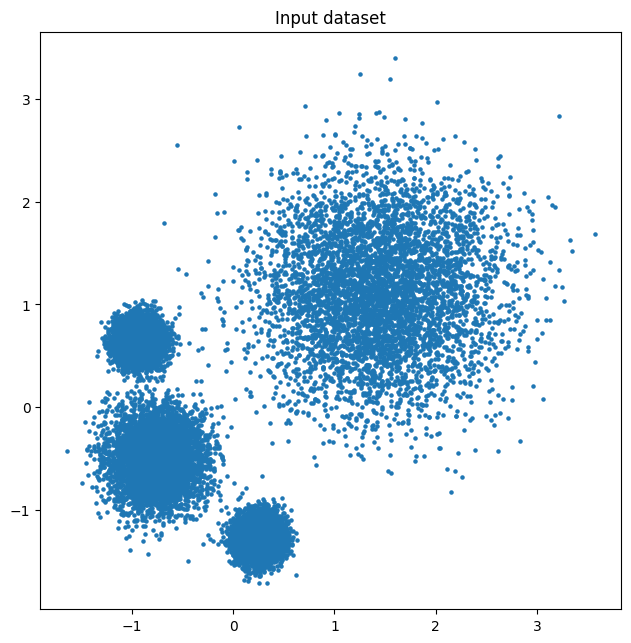

In [10]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "varied-variances.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

0.9968	0.999	0.999	0.9988	0.9986	0.999	0.9974	0.9989	0.6324	0.9989	
Avg. CA:  0.9619

Avg. RI:  0.983

Avg. RT:  4.2601
Avg. graph size: 976043.0


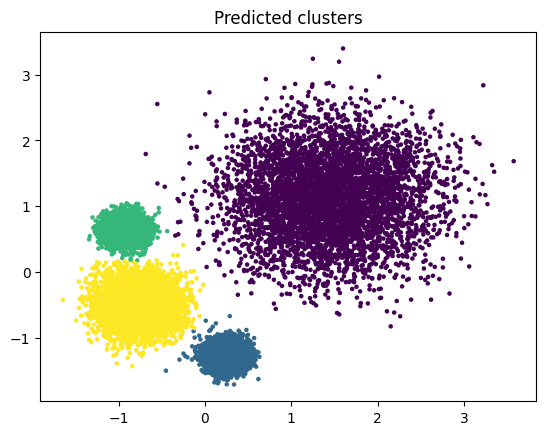

In [11]:
# set verbose=2 to save the results

nnz_avg, RT, CAs, RIs, pred_labels = kasp(X, K, num_iter=10, verbose=2, ds_name=filename, target_path=target_path)

print( "Avg. graph size:", nnz_avg )

# Visualizing results for 2-d datasets
if f == 2:
    max_ca_idx = np.argmax(CAs)
    # Plotting best results
    plt.scatter( X[:, 0], X[:, 1], c=pred_labels[:, max_ca_idx], s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()

# LSC

## Get landmarks

In [12]:
def get_rep_points(X, p, method = 'random'):
    N, f = X.shape
    if method == 'random':
        return np.random.permutation(N)[:p]
        # return np.arange(p)
    elif method == 'k-means':
        kmeans = KMeans(n_clusters=p, init='random', n_init=1, max_iter=50)
        kmeans.fit(X)
        return kmeans.cluster_centers_
    else:
        print("incorrect method name")

## LCS

In [13]:
def lsc(X, K, p=1000, k=5, rep_method='random', num_iter=10, max_iter=300, verbose=0, ds_name='undefined', target_path=""):

    labels_all = []
    CA_all = []
    RI_all = []

    bt = time.process_time()

    nnz_avg = 0

    for iter in range(num_iter):

        r = k
        np.random.seed(int(time.time()))
        rep_i = get_rep_points(X, p, method=rep_method)
        if rep_method == 'random':
            X_rep = X[rep_i]
        else:
            X_rep = rep_i

        # k-nearest landmarks
        Z = lil_matrix((p, N), dtype='float32')
        s = 0

        for i in range(N):
            dist = distance.cdist( [X[i]], X_rep )[0]
            Z_i = np.argsort(dist)
            dists = dist[ Z_i[:r] ]
            s += dists.sum()
            Z[ Z_i[:r], i ] = dists

        h = s / (N * r)

        del dist, Z_i
        Z = coo_matrix(Z)
        np.exp((- Z.power(2) / (2 * h ** 2)).data, out = Z.data)
        sum_0 = np.array(Z.sum(axis=0))[0] + 1e-10
        Z.data = Z.data / sum_0[Z.col]

        nnz = len(Z.nonzero()[0])

        nnz_avg += nnz

        # eigenvectors projection
        D_cap = np.diag(np.array(Z.sum(axis=1)).reshape(p) + 1e-10)

        try:
            D_cap = np.linalg.inv(sqrtm(np.nan_to_num(D_cap)))
        except:
            print("inv", end='')

        Z_cap = csr_matrix(D_cap) * csr_matrix(Z)

        del Z, D_cap

        vals, vecs = np.linalg.eig(np.nan_to_num((Z_cap * Z_cap.T).toarray()))
        k_largest = np.argsort(vals.real)[-K::]
        vals = vals[k_largest].real
        vecs = vecs[:,k_largest].real

        B = (csr_matrix(np.matmul( np.linalg.inv(np.diag(vals)), vecs.T )) * Z_cap).T
        del vecs, Z_cap

        B = np.nan_to_num(B.toarray().real)

        max_ca = 0
        max_labels = None

        for __i in range(15):
            kmeans = KMeans(n_clusters=K, init='random', n_init=1, max_iter=max_iter)
            kmeans.fit(B)
            labels = kmeans.labels_

            ca = clustering_accuracy(lab, labels)

            if ca > max_ca:
                max_labels = labels
                max_ca = ca

        labels_all.append(max_labels.tolist())
        CA_all.append(max_ca)
        RI_all.append( rand_index_score( lab, max_labels ) )

        if verbose > 0: print( round( max_ca, 4 ), end='\t' )

    t = time.process_time() - bt

    t /= num_iter

    nnz_avg /= num_iter

    avg_ca = np.mean(CA_all)
    print("\nAvg. CA: ", round(avg_ca, 4), "(", round(np.std(CA_all), 3), ")")

    avg_ri = np.mean(RI_all)
    print("\nAvg. RI: ", round(avg_ri, 4), "(", round(np.std(RI_all), 3), ")")

    print("\nAvg. RT: ", round(t, 4))



    max_labels = labels_all[ np.argmax(CA_all) ]
    max_ca = max(CA_all)
    labels_arr = np.array(labels_all).T

    if verbose > 1:


        df1 = pd.DataFrame(labels_arr)
        df1.to_csv(target_path + "/lsc-" + rep_method[0] + "-pred-labels-" + ds_name[:-4] + ".csv", sep=",", header=None, index=None)

    return np.ceil(nnz_avg), t, CA_all, RI_all, labels_arr

## Test

(20000, 2) 4


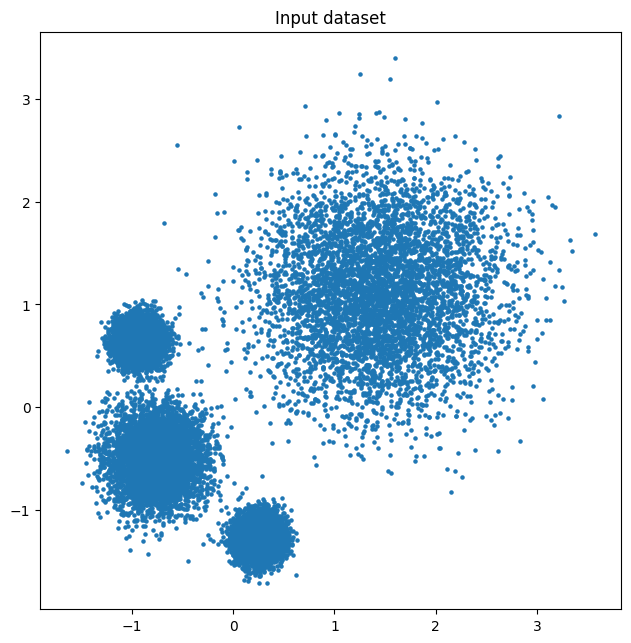

In [14]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "varied-variances.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

## Run LSC-R

0.9988	0.9991	0.999	0.9988	0.9978	0.997	0.9962	0.9986	0.9988	0.9976	
Avg. CA:  0.9982 ( 0.001 )

Avg. RI:  0.9982 ( 0.001 )

Avg. RT:  4.1718
Avg. graph size: 98982.0


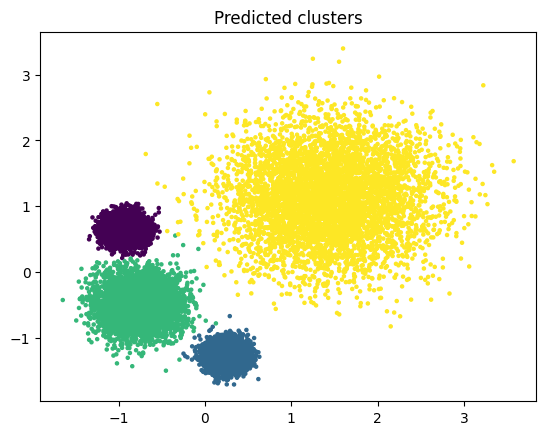

In [15]:
# set verbose=2 to save the results

nnz_avg, RT, CAs, RIs, pred_labels = lsc(X, K, num_iter=10, rep_method='random', verbose=2, ds_name=filename, target_path=target_path)

print( "Avg. graph size:", nnz_avg )

# Visualizing results for 2-d datasets
if f == 2:
    max_ca_idx = np.argmax(CAs)
    # Plotting best results
    plt.scatter( X[:, 0], X[:, 1], c=pred_labels[:, max_ca_idx], s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()

## Run LSC-K

0.9987	0.999	0.9988	0.9988	0.9988	0.9989	0.9986	0.9988	0.9988	0.9986	
Avg. CA:  0.9988 ( 0.0 )

Avg. RI:  0.9988 ( 0.0 )

Avg. RT:  4.8436
Avg. graph size: 99990.0


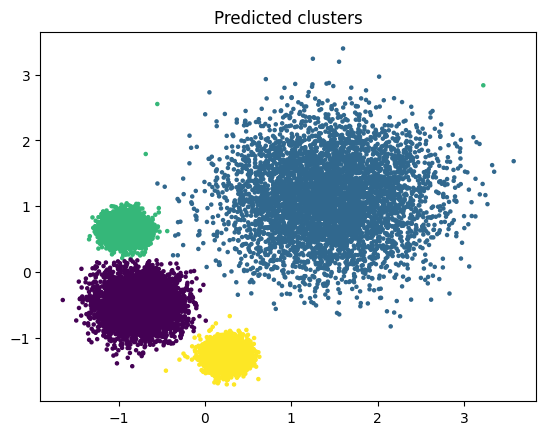

In [16]:
# set verbose=2 to save the results

nnz_avg, RT, CAs, RIs, pred_labels = lsc(X, K, num_iter=10, rep_method='k-means', verbose=2, ds_name=filename, target_path=target_path)

print( "Avg. graph size:", nnz_avg )

# Visualizing results for 2-d datasets
if f == 2:
    max_ca_idx = np.argmax(CAs)
    # Plotting best results
    plt.scatter( X[:, 0], X[:, 1], c=pred_labels[:, max_ca_idx], s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()

# USPEC

## Rep Points (Hybrid)

In [17]:
def get_reps(X, p=1000):
    p_dash = p * 10
    points_random = X[np.random.permutation(N)[:p_dash]]
    R = KMeans(n_clusters=p, init='random', n_init=1, max_iter=20).fit(points_random).cluster_centers_
    return R


Approx k-neighbors

In [18]:
def approx_near_neighbors(X, R, p=1000, k=5):

    N, f = X.shape
    KM_R = KMeans(n_clusters=int(np.ceil(R.shape[0] ** 0.5)), init='random', n_init=1, max_iter=10).fit(R)
    R_cluster_centers, R_cluster_labels = KM_R.cluster_centers_, KM_R.labels_
    R_clusters = [[] for i in range(len(set(R_cluster_labels)))]

    for i in range(len(R_cluster_labels)):
        R_clusters[R_cluster_labels[i]].append(i)

    k_dash = 10 * k
    dist_R = distance.cdist(R, R)
    R_i = np.argsort(dist_R)

    R_clusters_i = distance.cdist(X, R_cluster_centers).argmin(axis=1)

    A = lil_matrix((N, p), dtype='float32')

    for i in range(N):

        R_ci = R[ R_clusters[ R_clusters_i[i] ] ]
        rlii = distance.cdist([X[i]], R_ci)[0].argmin()
        rl = R_ci[rlii]
        rli = R_clusters[ R_clusters_i[i] ][rlii]
        k_dash_neighbors_rl = R_i[rli][:k_dash+1]
        D_x2r = distance.cdist([X[i]], R[k_dash_neighbors_rl])[0]
        k_neighbors_xi = k_dash_neighbors_rl[ D_x2r.argsort()[:k] ]
        A[i, k_neighbors_xi] = distance.cdist([X[i]], R[k_neighbors_xi])[0]

    h = A.sum() / (N * k)
    A = csr_matrix(A)
    np.exp((- A.power(2) / (2 * h ** 2)).data, out = A.data)

    return A

In [19]:
def t_cut(A, K):

    N, p = A.shape

    B = A

    dx = np.sum(B, 1, dtype='float32')

    dx = 1 / (dx + 1e-10)

    Dx = diags(np.array(dx, dtype='float32').reshape(N))
    Dx = np.nan_to_num(Dx)

    Er = ( B.T @ Dx @  B ).toarray()

    d = np.sum(Er.real, 1);
    d = 1 / np.sqrt(d + 1e-10)
    D = np.zeros((p, p))
    np.fill_diagonal(D, d)
    nWy = D @ Er @ D
    where_are_NaNs = np.isnan(nWy)

    nWy[where_are_NaNs] = 0
    nWy = (nWy + nWy.T) / 2

    aval, avec = np.linalg.eig(nWy)

    del d, dx, nWy, Er

    idx = np.argsort(aval)[::-1]
    Ncut_avec = D @ avec[:,idx[:K]].real
    where_are_NaNs = np.isnan(Ncut_avec)
    Ncut_avec[where_are_NaNs] = 0

    res = Dx @ B @ Ncut_avec
    res = np.nan_to_num(res)

    res = res / np.reshape(np.linalg.norm(res, axis=1) + 1e-10, (res.shape[0], 1))

    return res

In [20]:
def k_means(data, K, max_iter=300):

    max_ca = 0
    best_labels = None

    for iter in range(15):

        kmeans = KMeans(n_clusters=K, init='random', n_init=1, max_iter=max_iter)
        kmeans.fit(data)

        labels = kmeans.labels_

        ca = clustering_accuracy(lab, labels)

        if ca > max_ca:
            best_labels = labels
            max_ca = ca

    return max_ca, best_labels

## USPEC

In [21]:
def uspec(X, K, p=1000, k=5, num_iter=10, max_iter=300, verbose=0, ds_name='undefined', target_path=""):

    N, f = X.shape

    labels_all = []
    CA_all = []
    RI_all = []

    nnz_avg = 0

    btt = time.process_time()

    for iter in range(num_iter):

        R = get_reps(X, p)

        A = approx_near_neighbors(X, R, p, k)

        nnz = len(A.nonzero()[0])

        nnz_avg += nnz

        res = t_cut(A, K)

        max_ca, max_labels = k_means(res.real, K, max_iter=max_iter)

        labels_all.append(max_labels.tolist())
        CA_all.append(max_ca)
        RI_all.append( rand_index_score( lab, max_labels ) )

        if verbose > 0: print( round( max_ca, 4 ), end='\t' )

    ti = time.process_time() - btt
    ti /= num_iter

    nnz_avg /= num_iter

    avg_ca = np.mean(CA_all)
    print("\nAvg. CA: ", round(avg_ca, 4), "(", round(np.std(CA_all), 3), ")")

    avg_ri = np.mean(RI_all)
    print("\nAvg. RI: ", round(avg_ri, 4), "(", round(np.std(RI_all), 3), ")")

    print("\nAvg. RT: ", round(ti, 4))

    max_labels = labels_all[ np.argmax(CA_all) ]
    labels_arr = np.array(labels_all).T
    max_ca = max(CA_all)

    if verbose > 1:

        df1 = pd.DataFrame(labels_arr)
        df1.to_csv(target_path + "/uspec-pred-labels-" + ds_name[:-4] + ".csv", sep=",", header=None, index=None)


    return np.ceil(nnz_avg), ti, CA_all, RI_all, labels_arr

## Test

(20000, 2) 4


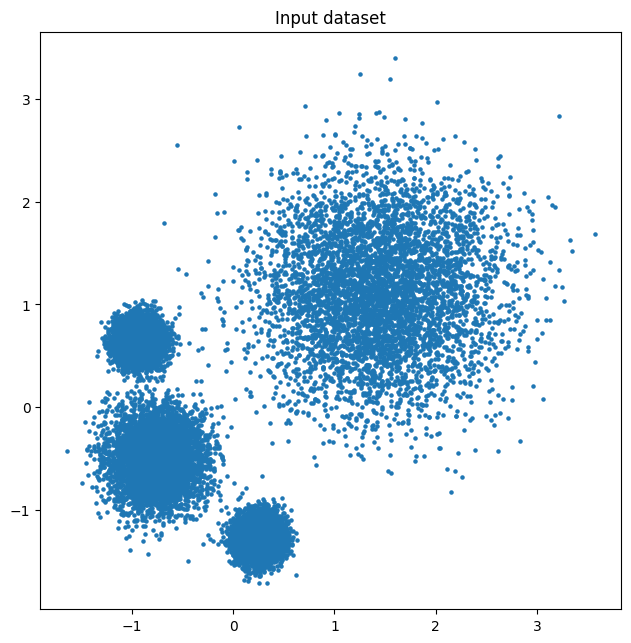

In [22]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "varied-variances.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

0.9983	0.9988	0.7492	0.7494	0.9987	0.9985	0.9987	0.9976	0.9984	0.9988	
Avg. CA:  0.9486 ( 0.1 )

Avg. RI:  0.9735 ( 0.05 )

Avg. RT:  4.0892
Avg. graph size: 99985.0


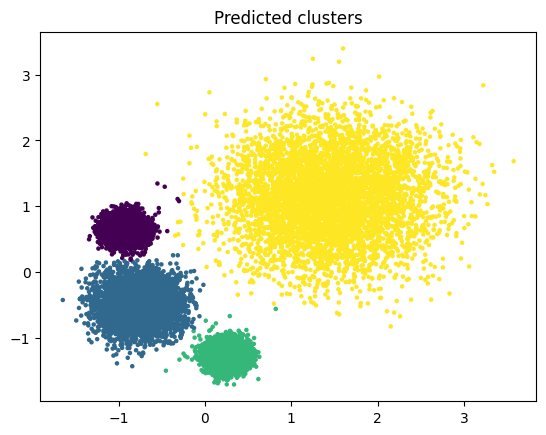

In [23]:
# set verbose=2 to save the results

nnz_avg, RT, CAs, RIs, pred_labels = uspec(X, K, num_iter=10, verbose=2, ds_name=filename, target_path=target_path)

print( "Avg. graph size:", nnz_avg )

# Visualizing results for 2-d datasets
if f == 2:
    max_ca_idx = np.argmax(CAs)
    # Plotting best results
    plt.scatter( X[:, 0], X[:, 1], c=pred_labels[:, max_ca_idx], s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()

# DnC

## Compute landmarks

In [24]:
def set_ks(P):
    if len(P) == 1:
        intP = P.astype(int)
        return intP
    intP = np.ceil(P).astype(int)
    sumright = np.round(P.sum()).astype(int)
    intP[intP < 1] = 1
    diff = intP.sum() - sumright

    while diff > 0:
        idx = intP > 1
        u = intP[idx].min()
        idx_u = (intP == u)
        n = np.sum(idx_u)

        if diff < (u - 1) * n:

            ni = int(np.floor( diff / (u - 1) ))

            randSample = np.zeros(n, dtype = bool)
            # print( u, n, ni, randSample)
            randSample[ np.random.permutation(n) [ :ni] ] = True
            selectedIdx, restIdx = np.array(idx_u), np.array(idx_u)
            selectedIdx[ idx_u ] = randSample
            # print(randSample, np.invert(randSample))
            restIdx[ idx_u ] = np.invert( randSample )

            randSample = np.zeros(n - ni, dtype = bool)
            randSample[ np.random.permutation(n - ni) [ :1] ] = True
            restIdx[ restIdx ] = randSample

            intP[ selectedIdx ] = 1

            intP[ restIdx ] = intP[restIdx] - ( diff - ni * (u - 1) )

            diff = 0
        else:

            intP[ idx_u ] = 1
            diff = diff - (u - 1) * n

    if diff < 0:
        print('Wrong')

    return intP

In [25]:
def get_landmarks(X, p, p_dash, alpha):

    N, d = X.shape
    centers = np.zeros( (1, d), dtype='float32' )

    sumD = np.ones( 1 )
    n_subsets = 1
    S = [np.arange(N)]

    while n_subsets < p:

        ks = np.array( sumD )
        ks = set_ks( ks / ks.sum() * p )
        ks[ ks > alpha ] = alpha
        new_S = []

        sumD = []
        R = []

        for i in range( n_subsets ):

            k = ks[ i ]
            # print(k)

            if k == 1:
                new_S.append(np.array(S[i]))
                points = X[ S[i] ]
                R.append( np.mean(points, axis = 0) )
                sumD.append( np.sum( ( points - R[-1] ) ** 2 ) )
                continue

            Ni = len(S[i])
            max_iteraiton = 10
            temp_labels = np.zeros(Ni, dtype=int)
            idx = np.array( S[i] )
            # print(Ni, p_dash)

            if Ni > p_dash:

                # idx1 = np.array( S[i] )
                np.random.shuffle(idx)
                H_idx = idx[ :p_dash ]
                Hc_idx = idx[ p_dash: ]

                H = X[H_idx]
                Hc = X[Hc_idx]

                km = KMeans(n_clusters=k, max_iter=max_iteraiton, n_init=1)
                km.fit(H)
                temp_labels[ :p_dash ] = km.labels_

                temp_centers = km.cluster_centers_
                dists = distance.cdist(Hc, temp_centers)
                temp_labels[ p_dash: ] = dists.argmin( axis = 1 )

            else:

                if Ni <= k: k = min( Ni, 2 )

                km = KMeans(n_clusters=k, max_iter=max_iteraiton, n_init=1)
                km.fit( X[ S[i] ] )
                temp_labels = km.labels_

            for cno in set(temp_labels):

                new_idx = idx[ np.where( temp_labels == cno ) ]
                new_S.append( new_idx )

                points = X[ new_idx ]
                R.append( np.mean(points, axis = 0) )
                sumD.append( np.sum( ( points - R[-1] ) ** 2 ) )

        S = new_S

        n_subsets = len(S)

        # print(n_subsets)

        labels = np.zeros(N, dtype=int)
        for i in range( len(S) ):
            labels[S[i]] = i
        # plt.scatter(X[:, 0], X[:, 1], c=labels)
        # plt.show()

    return labels, np.array(R), S

## T-Cut

In [26]:
def t_cut(A, K):

    N, p = A.shape

    B = A

    dx = np.sum(B, 1, dtype='float32')

    dx = 1 / (dx + 1e-10)

    Dx = diags(np.array(dx, dtype='float32').reshape(N))
    Dx = np.nan_to_num(Dx)

    Er = ( B.T @ Dx @  B ).toarray()

    d = np.sum(Er.real, 1);
    d = 1 / np.sqrt(d + 1e-10)
    D = np.zeros((p, p))
    np.fill_diagonal(D, d)
    nWy = D @ Er @ D
    where_are_NaNs = np.isnan(nWy)

    nWy[where_are_NaNs] = 0
    nWy = (nWy + nWy.T) / 2

    aval, avec = np.linalg.eig(nWy)

    del d, dx, nWy, Er

    idx = np.argsort(aval)[::-1]
    Ncut_avec = D @ avec[:,idx[:K]].real
    where_are_NaNs = np.isnan(Ncut_avec)
    Ncut_avec[where_are_NaNs] = 0

    res = Dx @ B @ Ncut_avec
    res = np.nan_to_num(res)

    res = res / np.reshape(np.linalg.norm(res, axis=1) + 1e-10, (res.shape[0], 1))

    return res

In [27]:
def k_means(data, K, max_iter=300):

    max_ca = 0
    best_labels = None

    for iter in range(15):

        kmeans = KMeans(n_clusters=K, init='random', n_init=1, max_iter=max_iter)
        kmeans.fit(data)

        labels = kmeans.labels_

        ca = clustering_accuracy(lab, labels)

        if ca > max_ca:
            best_labels = labels
            max_ca = ca

    return max_ca, best_labels

## DnC

In [28]:
def dnc(X, K, p=1000, k=5, alpha=200, num_iter=10, max_iter=300, verbose=0, ds_name='undefined', target_path=""):

    N, f = X.shape

    labels_all = []
    CA_all = []
    RI_all = []

    nnz_avg = 0

    btt = time.process_time()

    for iter in range(num_iter):

        p_dash = p * 10
        S_labels, R, S = get_landmarks(X, p, p_dash, alpha)

        k_dash = 10 * k
        dist_R = distance.cdist(R, R).astype('float32')
        R_i = np.argsort(dist_R)
        del dist_R

        A = lil_matrix((N, p), dtype='float32')
        for i in range(N):

            ri = S_labels[i]
            dists = np.array(R_i[ ri ], dtype='int')
            k_dash_nn = dists[ :k_dash ]
            # k_dash_nn = np.argsort( dist_R[ri] )[ 1:k_dash ]

            dists = distance.cdist( [ X[i] ], R[ k_dash_nn ] ).astype('float32')[0]
            k_nn = dists.argsort() [ :k ]

            A[ i, k_dash_nn[ k_nn ] ] = dists[ k_nn ]

        del R_i
        h = A.sum() / (N * k)
        A = csr_matrix(A, dtype='float32')
        np.exp((- A.power(2) / (2 * h ** 2)).data, out = A.data)

        nnz = len(A.nonzero()[0])

        nnz_avg += nnz


        res = t_cut(A, K)

        del A

        max_ca, max_labels = k_means(res.real, K, max_iter=max_iter)

        labels_all.append(max_labels.tolist())
        CA_all.append(max_ca)
        RI_all.append(rand_index_score(lab, max_labels))

        if verbose > 0: print( round( max_ca, 4 ), end='\t' )

    ti = time.process_time() - btt
    ti /= num_iter

    nnz_avg /= num_iter


    avg_ca = np.mean(CA_all)
    print("\nAvg. CA: ", round(avg_ca, 4))

    avg_ri = np.mean(RI_all)
    print("\nAvg. RI: ", round(avg_ri, 4))

    print( "\nAvg. RT: ", round(ti, 4) )

    max_labels = labels_all[ np.argmax(CA_all) ]
    labels_arr = np.array(labels_all).T
    max_ca = max(CA_all)

    if verbose > 1:

        df1 = pd.DataFrame(labels_arr)
        df1.to_csv(target_path + "/dnc-pred-labels-" + ds_name[:-4] + ".csv", sep=",", header=None, index=None)


    return np.ceil(nnz_avg), ti, CA_all, RI_all, labels_arr

## Test

(20000, 2) 4


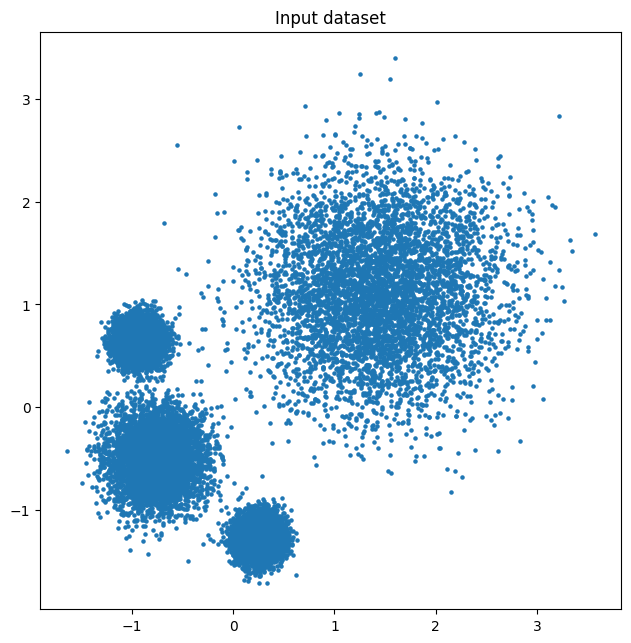

In [29]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "varied-variances.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

alpha = 200 if N < 100000 else 50

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

0.9986	0.9987	0.9989	0.999	0.9922	0.9982	0.9989	0.999	0.9981	0.999	
Avg. CA:  0.9981

Avg. RI:  0.9981

Avg. RT:  4.1313
Avg. graph size: 99949.0


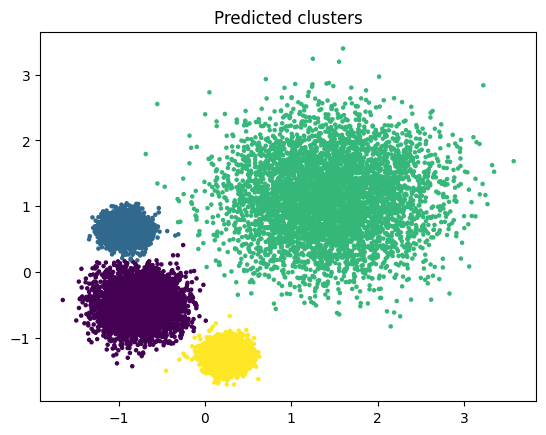

In [30]:
# set verbose=2 to save the results

nnz_avg, RT, CAs, RIs, pred_labels = dnc(X, K, alpha=alpha, num_iter=10, verbose=2, ds_name=filename, target_path=target_path)

print( "Avg. graph size:", nnz_avg )

# Visualizing results for 2-d datasets
if f == 2:
    max_ca_idx = np.argmax(CAs)
    # Plotting best results
    plt.scatter( X[:, 0], X[:, 1], c=pred_labels[:, max_ca_idx], s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()

# KMeans

## Algorithm

In [31]:
def init_maxmin(X, k, is_plot=False):
  N, f = X.shape
  for no_c in range(k):
    if no_c == 0:
      m = int(np.random.random() * (N - 1))
      centroids = [X[m].tolist()]
    else:
      D_X2c = distance.cdist(X, centroids)
      X_min_c = D_X2c.argmin(axis = 1)
      dis_X2minc = np.sqrt(np.sum((centroids_arr[X_min_c] - X) ** 2, axis=1))
      m = np.argmax(dis_X2minc)
      centroids.append(X[m].tolist())
    # print(centroids)
    centroids_arr = np.array(centroids)
    if is_plot:
      plt.scatter(X[:, 0], X[:, 1])
      plt.scatter(centroids_arr[:, 0], centroids_arr[:, 1], c = 'red')
      plt.show()
  return centroids_arr

In [32]:
def km(X, K, init='random', num_iter=10, is_plot=False, verbose=0, target_path='', ds_name='undefined'):

    labels_all = []
    CA_all = []
    RI_all = []

    if verbose > 0: print("Running for the dataset of shape:", X.shape)

    max_ca = -1
    best = None

    for iter in range(num_iter):

        if init == 'maxmin':
            init_centroids = init_maxmin(X, K, is_plot=is_plot)
            kmeans = KMeans(K, init = init_centroids, n_init=1)
        elif init == 'random':
            kmeans = KMeans(K, init = 'random', n_init=1)
        else:
            print('unidentified initialization method')
            return

        kmeans.fit(X)
        labels = kmeans.labels_
        final_centroids = kmeans.cluster_centers_

        ca = clustering_accuracy(lab, labels)

        if ca > max_ca:
            best = labels
            max_ca = ca

        labels_all.append(labels.tolist())
        CA_all.append(ca)
        RI_all.append( rand_index_score(lab, labels) )

        if verbose > 0: print( round( ca, 4 ), end='\t' )

    avg_ca = np.mean(CA_all)
    print("\nAvg. CA: ", round(avg_ca, 4), "(", round(np.std(CA_all), 3), ")")

    avg_ri = np.mean(RI_all)
    print("\nAvg. RI: ", round(avg_ri, 4), "(", round(np.std(RI_all), 3), ")")

    max_labels = labels_all[ np.argmax(CA_all) ]
    labels_arr = np.array(labels_all).T

    if verbose > 1:

        df1 = pd.DataFrame(labels_arr)
        df1.to_csv(target_path + "/km-pred-labels-" + ds_name[:-4] + ".csv", sep=",", header=None, index=None)

    return CA_all, RI_all, labels_arr


## Test

(20000, 2) 4


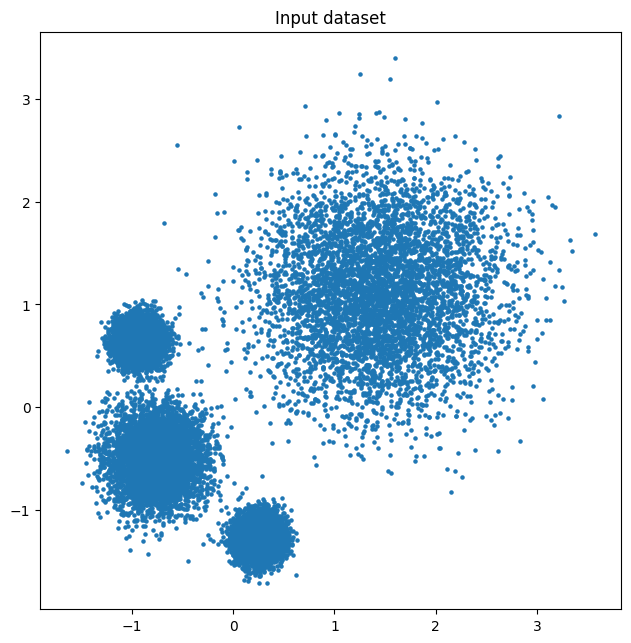

In [33]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "varied-variances.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

Running for the dataset of shape: (20000, 2)
0.9896	0.9896	0.9896	0.9896	0.6321	0.628	0.6249	0.9896	0.6335	0.9896	
Avg. CA:  0.8456 ( 0.176 )

Avg. RI:  0.9249 ( 0.079 )


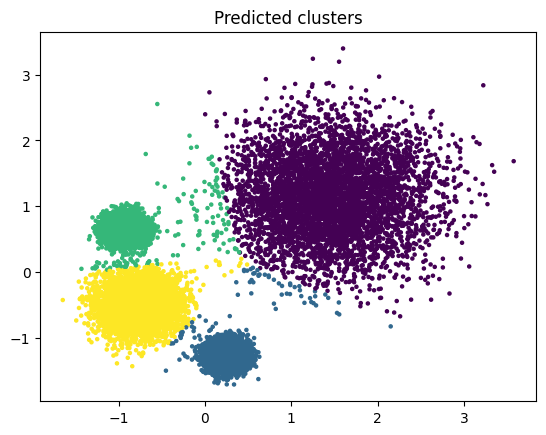

In [34]:
# set verbose=2 to save the results

CAs, RIs, pred_labels = km( X, K, num_iter=10,
                                 verbose=2, ds_name=filename, target_path=target_path )

# Visualizing results for 2-d datasets

if f == 2:
    max_ca_idx = np.argmax(CAs)


    # Plotting best results
    plt.scatter( X[:, 0], X[:, 1], c=pred_labels[:, max_ca_idx], s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()

# SC

## Algorithm

In [35]:
def knn_sc(X, K, num_iter=10, is_plot=False, verbose=0, ds_name='undefined', target_path="", max_iter=300):

    labels_all = []
    CA_all = []
    RI_all = []

    # Constructing graph

    bt = time.process_time()

    distances = distance.cdist(X, X).astype('float32')
    A_i = np.argsort(distances)

    r = math.ceil(np.log(N))
    A = lil_matrix((N, N), dtype='float32')

    for i in range(N):

        dist = distances[i, A_i[i][1: r+1]]
        A[i, A_i[i][1: r+1]] = dist
        A[A_i[i][1: r+1], i] = dist

    nnz = len(A.nonzero()[0])
    if verbose > 0: print( nnz, end='\t' )


    del distances


    # Eigen-decomposition step

    L_sym, D = laplacian(A, normed=True, use_out_degree=True, return_diag=True)
    del A
    vals, vecs = np.linalg.eigh(L_sym.toarray())
    vecs = vecs.real
    vecs = vecs[:, :K].real
    vecs = vecs / np.reshape(np.linalg.norm(vecs, axis=1), (vecs.shape[0], 1))
    vecs = np.nan_to_num(vecs)

    t1 = time.process_time() - bt

    bt = time.process_time()

    for iter in range(num_iter):

        bt = time.process_time()
        max_ca = -1
        best = None

        for i in range(15):

            kmeans = KMeans(n_clusters=K, n_init=1, init='random', max_iter=max_iter)
            kmeans.fit(vecs)

            labels = kmeans.labels_

            ca = clustering_accuracy(lab, labels)

            if ca > max_ca:
                best = labels
                max_ca = ca

        labels_all.append(best.tolist())
        CA_all.append(max_ca)
        RI_all.append( rand_index_score( lab, best ) )

        if verbose > 0: print( round( max_ca, 4 ), end='\t' )

    t2 = (time.process_time() - bt) / num_iter

    avg_ca = np.mean(CA_all)
    print("\nAvg. CA: ", round(avg_ca, 4), "(", round(np.std(CA_all), 4), ")")

    avg_ri = np.mean(RI_all)
    print("\nAvg. RI: ", round(avg_ri, 4), "(", round(np.std(RI_all), 4), ")")

    print("\nAvg. running time (sec): ", t1 + t2)

    max_labels = labels_all[ np.argmax(CA_all) ]
    labels_arr = np.array(labels_all).T
    max_ca = max(CA_all)

    if verbose > 1:

        df1 = pd.DataFrame(labels_arr)
        df1.to_csv("/knnsc-pred-labels-" + ds_name[:-4] + ".csv", sep=",", header=None, index=None)


    return nnz, t1 + t2, CA_all, RI_all, labels_arr


## Test

(240, 2) 2


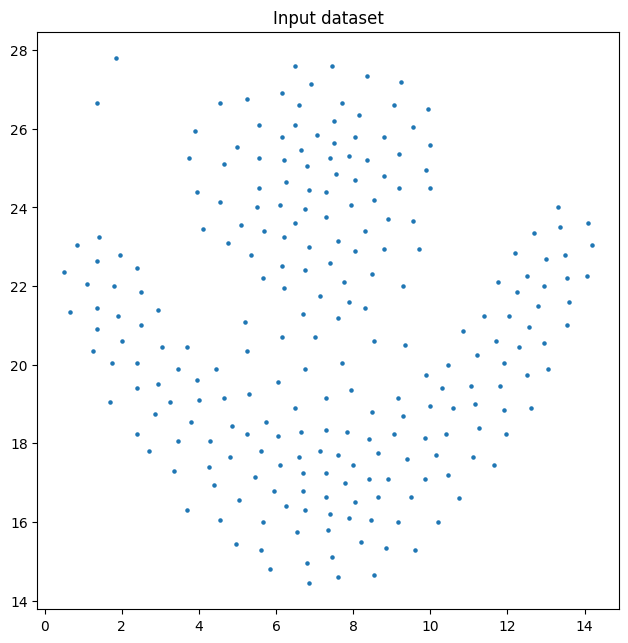

In [36]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "flame_k=2.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

1668	0.7917	0.7917	0.7917	0.7917	0.7917	0.7917	0.7917	0.7917	0.7917	0.7917	
Avg. CA:  0.7917 ( 0.0 )

Avg. RI:  0.6688 ( 0.0 )

Avg. running time (sec):  0.04670393999999476
Graph size: 1668


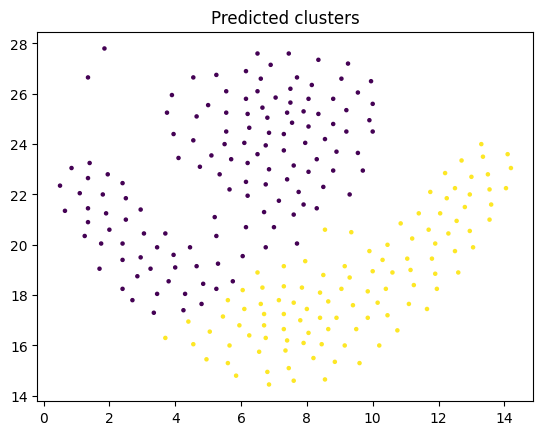

In [37]:
# set verbose=2 to save the results

graph_size, RT, CAs, RIs, pred_labels = knn_sc( X, K, num_iter=10,
                                 verbose=2, ds_name=filename, target_path=target_path )

# Visualizing results for 2-d datasets
print( "Graph size:", graph_size )
if f == 2:
    max_ca_idx = np.argmax(CAs)


    # Plotting best results
    plt.scatter( X[:, 0], X[:, 1], c=pred_labels[:, max_ca_idx], s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()


# DCDP-ASC

## Algorithm

In [38]:
def get_nighbors(X):

    N, f = X.shape

    li_knn = []
    r = 1
    nb = np.zeros(N, dtype='float32')

    if f < 200:
        tree = KDTree(X)

        prev_nb = 0
        max_r = 0
        diff = 10
        while True:
            if r >= max_r:
                max_r += diff
                D, D_sorted = tree.query(X, k=max_r)
            print("=" * 15, "running for r =", r, "=" * 15)
            qs = D_sorted[:, r]
            nb[qs] += 1

            s_nb = sum(nb == 0)
            li_knn.append(qs.tolist())

            print("prev s-nb", prev_nb)
            print("current n-sb", s_nb)

            if prev_nb == s_nb:
                break

            prev_nb = s_nb

            # print(D_sorted[:, r])

            r += 1
    else:
        prev_nb = 0
        max_r = 0
        diff = 500
        while True:
            if r >= max_r:
                max_r += diff
                nbrs = NearestNeighbors(n_neighbors=max_r).fit(X)
                D, D_sorted = nbrs.kneighbors(X)
            print("=" * 15, "running for r =", r, "=" * 15)
            qs = D_sorted[:, r]
            nb[qs] += 1

            s_nb = sum(nb == 0)
            li_knn.append(qs.tolist())

            print("prev s-nb", prev_nb)
            print("current n-sb", s_nb)

            if prev_nb == s_nb:
                break

            prev_nb = s_nb

            # print(D_sorted[:, r])

            r += 1
    # break
    lam = r

    knn = np.array(li_knn).T

    D, D_sorted = D[:, 1:r+1], D_sorted[:, 1:r+1]

    return r, knn, nb, D, D_sorted


In [39]:
def comp_density(X, knn, r, nb, D, D_sorted):

    N, f = X.shape

    k = max(nb)
    Den = np.zeros(N, dtype='float32')

    for i in range(N):

        Den[i] = k / np.sum(D[i])

    Den = np.nan_to_num(Den)
    Den_sorted_i = np.argsort(Den)[::-1]

    return Den, Den_sorted_i


In [40]:
def get_dcores(X, knn, Den, Den_sorted_i):

    Rep1 = np.zeros(N, dtype=int) + -1
    S = {}

    for i in Den_sorted_i:

        nn_i = knn[i]
        _i = Den[ nn_i ].argmax()
        y = nn_i[ _i ]
        D_nn_i = distance.cdist([X[y]], X[nn_i])[0]
        _j = 0

        for x in nn_i:

            if Rep1[x] == -1:

                prev = Rep1[x]
                Rep1[x] = y
                if S.get(y) == None: S[y] = set()
                S[y].add(x)
                if S.get(prev) != None: S[prev].discard(x)


            if Rep1[x] != y:

                z = Rep1[x]

                if D_nn_i[_j] <= distance.euclidean(X[x], X[z]):

                    prev = Rep1[x]
                    Rep1[x] = y
                    if S.get(y) == None:
                        S[y] = set()
                    S[y].add(x)
                    if S.get(prev) != None: S[prev].discard(x)
                else:
                    prev = Rep1[x]
                    Rep1[x] = z
                    if S.get(z) == None:
                        S[z] = set()
                    S[z].add(x)
                    if S.get(prev) != None: S[prev].discard(x)

                # points_x = np.where(Rep1 == x)[0].tolist()
            if S.get(x) == None:
                points_x = np.where(Rep1 == x)[0].tolist()
                points_x_set = set(points_x)
                S[x] = set(points_x_set)
            else:
                points_x = list(S[x])
                points_x_set = set(points_x)

            prev_x = Rep1[ points_x ]
            Rep1[ points_x ] = Rep1[x]

            if S.get(Rep1[x]) == None:
                S[Rep1[x]] = points_x_set
            else:
                S[Rep1[x]] = S[Rep1[x]] | points_x_set

            for _i in range(len(prev_x)):
                if S.get(prev_x[_i]) != None: S[prev_x[_i]].discard(points_x[_i])
            # if S.get(Rep1[x]) == None: S[Rep1[x]] = points_x
            # else: S[Rep1[x]].extend(points_x)

            _j += 1

    return Rep1

In [41]:
def select_dcores(X, Rep1, Den, Den_sorted_i, knn, alpha=0.0, is_plot=False):

    th = Den[ Den_sorted_i[-int(alpha * N + 1)] ]
    print("th:", th)

    print(Den[Den_sorted_i[-1]])

    DCOREs = []
    MDCOREs = {}
    Rep = np.array(Rep1)
    for x in range(N):
        if Rep[x] == x and Den[x] >= th:
            DCOREs.append(x)
            MDCOREs[x] = []

        if Rep[x] == x and Den[x] < th:
            D_x = distance.cdist([X[x]], X[DCOREs])[0]
            # D_x = D_og[x, DCOREs]
            if len(D_x) > 0:
                y = DCOREs[ D_x.argmin() ]
                Rep[ np.where(Rep == x)[0] ] = y

    print("# Dense Cores:", len(DCOREs))

    if is_plot:
        plt.figure(figsize=(8, 5.5))
        plt.scatter(X[:, 0], X[:, 1], s=50)
        X_cores = X[DCOREs]
        plt.scatter(X_cores[:, 0], X_cores[:, 1], color='C1', s=50)
        plt.show()

    Den_th = (Den >= th).astype('int')
    for x in DCOREs:
        MDCOREs[x].extend(np.where(((Rep == x).astype('int') * Den_th) == 1)[0].tolist())

    if is_plot:
        plt.figure(figsize=(12, 8))
        plt.scatter(X[:, 0], X[:, 1], s=60)
        X_cores = X[DCOREs]
        plt.scatter(X_cores[:, 0], X_cores[:, 1], color='C1', s=60)

        for i in DCOREs:
            for j in MDCOREs[i]:
                (x1, y1), (x2, y2) = X[i], X[j]
                plt.plot((x1, x2), (y1, y2), color='C1')
        plt.show()

    return DCOREs, MDCOREs, Rep, th

In [42]:
def get_distance_metrix(X, DCOREs, MDCOREs, knn, D_DCOREs, th, Den):

    ND = {}
    for p in DCOREs:
        li = []
        for q in MDCOREs[p]:
            li.extend(knn[q][np.where(Den[knn[q]] >= th)[0]])
        ND[p] = set(li)

    X_cores = X[DCOREs]
    D_DCOREs = distance.cdist(X_cores, X_cores).astype('float32')
    maxd = D_DCOREs.max()
    print(maxd)

    n = D_DCOREs.shape[0]
    h = 0
    n_h = 0
    ind = np.arange(n).reshape((n, 1))

    DCOREs_li = np.array(DCOREs, dtype=int)

    def CD(i, j):
        nonlocal h, n_h, DCOREs_li, ND, maxd, D_DCOREs
        i, j = i[0], j[0]
        p, q = DCOREs_li[i], DCOREs_li[j]
        CN_pq = ND[p] & ND[q]
        # print(CN_pq)
        if len(CN_pq) == 0: return maxd * D_DCOREs[i, j]
        else:
            cd = D_DCOREs[i, j] / ( len(CN_pq) * Den[list(CN_pq)].sum() )
            h += cd
            n_h += 1
            return cd

    D_CD = distance.cdist(ind, ind, metric=CD).astype('float32')

    del DCOREs_li, ND

    GD = shortest_path(csgraph=D_CD, method = 'FW', directed=False, return_predecessors=False)

    return GD.astype('float32'), h, n_h


In [63]:
def dcdp_asc( X, alpha=0.0, verbose=0, ds_name='undefined', target_path="", max_iter=300 ):

    bt = time.process_time()
    r, knn, nb, D, D_sorted = get_nighbors(X)
    Den, Den_sorted_i = comp_density(X, knn, r, nb, D, D_sorted)
    Rep1 =  get_dcores(X, knn, Den, Den_sorted_i)

    DCOREs, MDCOREs, Rep, th = select_dcores(X, Rep1, Den, Den_sorted_i, knn, alpha=alpha)

    GD, h, n_h = get_distance_metrix(X, DCOREs, MDCOREs, knn, DCOREs, th, Den)

    del nb, knn, D, D_sorted

    n = len(DCOREs)
    roh = Den[DCOREs]
    max_roh = roh.max()
    delta = np.zeros(n)
    for p in range(n):
        if roh[p] != max_roh:
            delta[p] = GD[p, np.where(roh > roh[p])[0]].min()
        else:
            temp = delta[p]
            delta[p] = -1
            delta[p] = delta.max()

    t1 = time.process_time() - bt

    plt.figure(figsize=(12, 8))
    plt.scatter(roh, delta, s=60)
    plt.xlabel( "roh" )
    plt.ylabel( "delta" )
    plt.show()

    print("\n\n" * 10)

    roh_th, delta_th = float(input("Enter threshold value for roh: ")), float(input("Enter threshold value for delta: "))


    bt = time.process_time()

    IC_i = np.where((roh > roh_th).astype('int8') * (delta > delta_th).astype('int8'))[0]
    K = len(IC_i)

    print(K, "preaks selected")

    sig = h / n_h
    A = (GD > 0) * ( np.exp( -(GD ** 2) / (2 * sig * sig)) )

    L_sym, D1 = laplacian(A, normed=True, use_out_degree=True, return_diag=True)
    vals, vecs = np.linalg.eigh(L_sym)
    vecs = vecs.real
    vecs = vecs[:, :K]
    vecs = vecs / np.reshape(np.linalg.norm(vecs, axis=1) + 1e-10, (vecs.shape[0], 1))
    t5 = time.process_time() - bt
    del L_sym, D1, A, GD

    kmeans = KMeans(n_clusters=len(IC_i), n_init=1, init=vecs[IC_i].real, max_iter=max_iter)
    kmeans.fit(np.nan_to_num(vecs.real))
    partition_labels = kmeans.labels_

    labels = np.zeros(N, dtype='int')
    for x in range(n):
        labels[DCOREs[x]] = partition_labels[x]

    for x in range(N):
        labels[x] = labels[Rep[x]]

    ca = clustering_accuracy(lab, labels)
    ri = rand_index_score(lab, labels)

    t2 = time.process_time() - bt

    print("\nCA: ", round(ca, 4))

    print("\nRI: ", round(ri, 4))

    print("\nRunning time (sec): ", t1 + t2)

    labels_arr = np.array([labels]).T

    if verbose > 1:

        df1 = pd.DataFrame(labels_arr)
        df1.to_csv("/dcdpasc-pred-labels-" + ds_name[:-4] + ".csv", sep=",", header=None, index=None)


    return t1 + t1, ca, ri, labels_arr.flatten()

## Test

(240, 2) 2


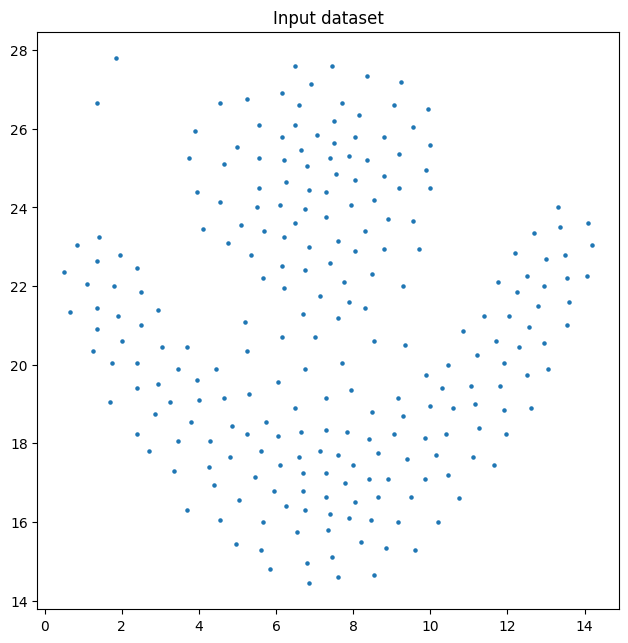

In [44]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "flame_k=2.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

=============== running for r = 1 ===============
prev s-nb 0
current n-sb 73
=============== running for r = 2 ===============
prev s-nb 73
current n-sb 13
=============== running for r = 3 ===============
prev s-nb 13
current n-sb 2
=============== running for r = 4 ===============
prev s-nb 2
current n-sb 0
=============== running for r = 5 ===============
prev s-nb 0
current n-sb 0
th: 0.3652703
0.3652703
# Dense Cores: 110
12.450904


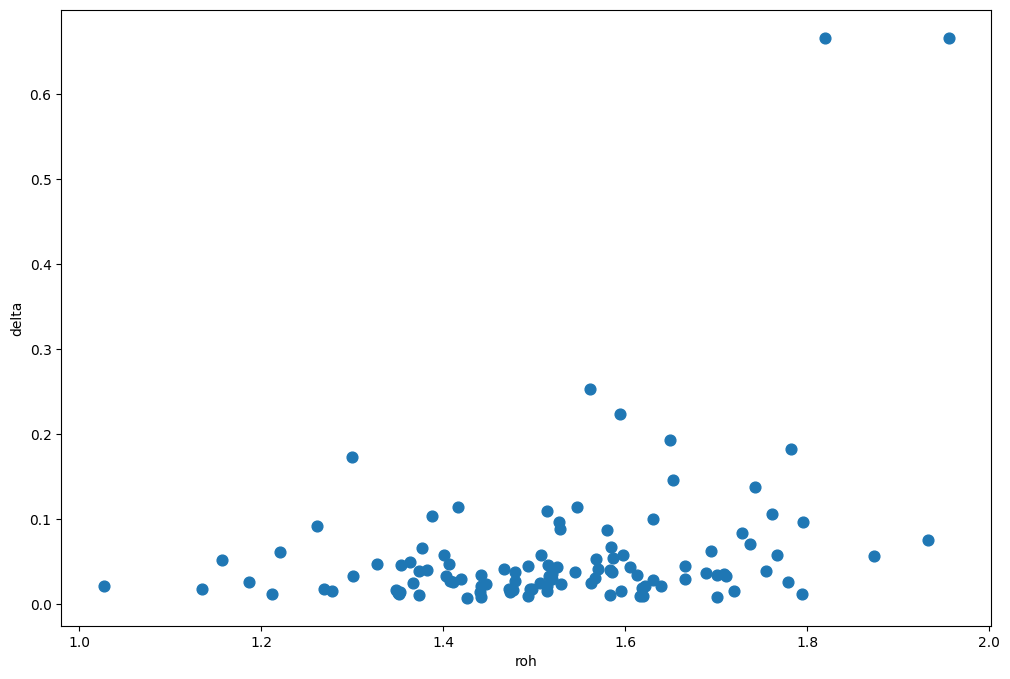






















Enter threshold value for roh: 1.8
Enter threshold value for delta: 0.6
2 preaks selected

CA:  0.9792

RI:  0.959

Running time (sec):  0.09778298099996618


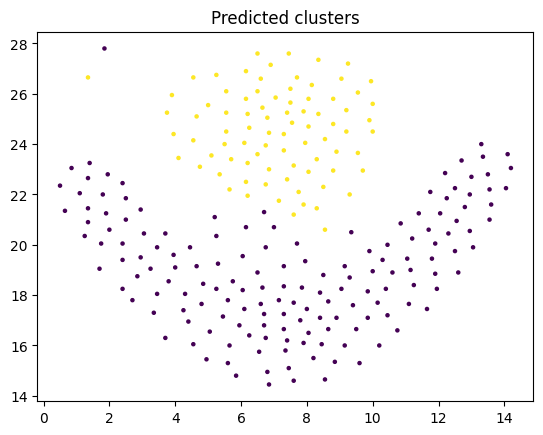

In [48]:
alpha = 0.0 # set non-zero (less than 1) for large datasets like 0.5 or 0.7

# Also, to select peaks, you have to select roh and delta threshold values and give as inputs based on the decision graph during the execution of the algorithm

RT, CA, RI, pred_label = dcdp_asc( X, alpha=alpha, verbose=2, ds_name=filename, target_path=target_path )

# Visualizing results for 2-d datasets
if f == 2:
    plt.scatter( X[:, 0], X[:, 1], c=pred_label, s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()


# Proposed clustering algorithm (SBSC)

In [49]:
!python setup.py build_ext --inplace
import k_mst2

running build_ext
copying build/lib.linux-x86_64-cpython-312/k_mst2.cpython-312-x86_64-linux-gnu.so -> 


### Phase I: Determining $O(N^{1/2})$ representatives using partitioning

In [50]:
def bi_means(X, X_indices, max_size, P_dash, C_dash):

    X_partition = X[X_indices]

    if len(X_indices) > max_size:

        X_indices_arr = np.array(X_indices)

        center = X_partition.mean(axis=0)

        distances = distance.cdist([center], X_partition)
        p_index = distances[0].argmax() # farthest point from rep_point

        distances = distance.cdist([X_partition[p_index]], X_partition)
        q_index = distances[0].argmax() # farthest point from p

        distances = distance.cdist(X_partition, [X_partition[p_index], X_partition[q_index]])

        min_i = distances.argmin(axis = 1)

        p_min_Is = np.where(min_i == 0)[0]
        q_min_Is = np.where(min_i == 1)[0]

        bi_means(X, X_indices_arr[p_min_Is], max_size, P_dash, C_dash)
        bi_means(X, X_indices_arr[q_min_Is], max_size, P_dash, C_dash)
    else:
        P_dash.append(X_indices)
        C_dash.append(X_partition.mean(axis=0))

In [51]:
def determine_reps(X, k_dash=10, is_plot=False):

    N, f = X.shape

    P_dash = []
    C_dash = []

    vertices = np.arange(N)

    max_size = k_dash * math.ceil(N ** 0.5)

    bi_means(X, vertices, max_size, P_dash, C_dash)
    C_dash = np.array(C_dash, dtype='float32')

    if is_plot:
        i = 0
        plt.figure(figsize = (7.5, 7.5))
        for Pj in P_dash:
            X_p = X[Pj]
            plt.scatter(X_p[:, 0], X_p[:, 1], color=marker_colors[i % 200], s=60)
            i += 1
        plt.scatter(C_dash[:, 0], C_dash[:, 1], color='C3', marker='*', edgecolor='black', linewidth=1.5, s = 300)
        plt.title("Partitions after stage-1", fontsize=20, fontweight='bold')
        plt.show()

    P = []
    R = []

    for Pj in P_dash:

        X_p = X[Pj]

        Nj = len(Pj)

        n_clusters = k_dash if Nj > k_dash else 2

        if Nj <= n_clusters and Nj > 2:
            n_clusters = 2

        if Nj <= n_clusters:
            P.append( list(Pj) )
            R.append( X_p.mean(axis=0) )
        else:
            temp_P_dash = []
            temp_C_dash = []

            max_size = math.ceil( math.ceil( Nj / n_clusters ) )
            bi_means(X, Pj, max_size, temp_P_dash, temp_C_dash)

            no_clusters = len(temp_C_dash)
            kmeans = KMeans(n_clusters=no_clusters, max_iter=20, n_init=1, init=np.array(temp_C_dash))
            kmeans.fit(X_p)

            labels = kmeans.labels_

            for i in range(no_clusters):
                R.append(kmeans.cluster_centers_[i])
                P.append( Pj[ np.where(labels == i)[0] ] )

    R = np.array(R, dtype='float32')

    if is_plot:
        i = 0
        plt.figure(figsize = (7.5, 7.5))
        for Pj in P:
            X_p = X[Pj]
            plt.scatter(X_p[:, 0], X_p[:, 1], color=marker_colors[i % 200], s=60)
            i += 1
        plt.scatter(R[:, 0], R[:, 1], color='C3', marker='*', edgecolor='black', linewidth=1.5, s = 300)
        plt.title('Final partitions after stage-2', fontsize=20, fontweight='bold')
        plt.show()

    return P, R, P_dash, C_dash

## Phase II: Finding neighbors and two-hops neighbors of representatives using MST

In [52]:
def neighboring_reps(R, num_rounds=2, is_plot=False):
    cen_distances = distance.cdist(R, R).astype('float32')

    n = len(R)
    MST_CEN = []

    us, vs = np.triu_indices(n, 1)
    us = us.astype('int32')
    vs = vs.astype('int32')
    ws = cen_distances[us, vs]
    sorted_ws = np.argsort(ws)
    vertices = np.arange(n, dtype=int).tolist()

    for _ite in range(num_rounds):

        parent = np.arange(n, dtype='int32')
        rank = np.zeros(n, dtype='int32')
        _MST_CEN = np.zeros(( n - 1, 3 ), dtype='float32')
        k_mst2.k_mst(_ite, sorted_ws, us, vs, ws, parent, rank, _MST_CEN, n)

        MST_CEN += _MST_CEN.tolist()

    neighbors = [[i] for i in range(n)]
    for edge in MST_CEN:
        u, v, w = edge
        u, v = int(u), int(v)
        neighbors[u].append(v)
        neighbors[v].append(u)

    neighbors_arr = np.array(neighbors, dtype='object')

    if is_plot:
        plt.figure(figsize = (7.5, 7.5))
        plt.scatter(R[:, 0], R[:, 1], color='C3', marker='*', edgecolor='black', linewidth=1.5, s = 400, zorder=1)

        for edge in MST_CEN:
            u, v, w = edge
            u, v = int(u), int(v)
            (x1, y1), (x2, y2) = R[u], R[v]
            plt.plot( (x1, x2),  (y1, y2), c='black', linewidth=5, zorder=0)

        plt.title('Neighboring representatives', fontsize=20, fontweight='bold')
        plt.show()

    return MST_CEN, neighbors_arr


## Phase III: Approximate searching to construct the bipartite proximity graph

In [53]:
def build_bip_graph(X, K, P, R, num_rounds=2, is_plot=False):
    ti = time.process_time()

    M2, NN = neighboring_reps(R, num_rounds=num_rounds, is_plot=is_plot)

    N = len(X)
    p = len(R)
    A = lil_matrix((N, p), dtype='float32')

    for i in range(p):

        X_i = np.array(P[i])

        NN2 = np.array( list( set( sum( NN[ NN[i] ], [] ) ) ) )

        dists = distance.cdist(X[X_i], R[NN2])

        r = len( NN[i] ) - 1

        dists_sorted = dists.argsort(axis=1)

        r_dists = dists_sorted[:, :r]
        nr = r_dists.shape[1]
        nn = len(X_i)
        U = np.array(np.arange(nn).tolist() * nr).reshape(nr, nn).T.flatten().tolist()
        V = r_dists.flatten().tolist()

        s1 = dists[U, V].flatten()
        A[X_i[U], NN2[V]] = s1

    if is_plot:
        A1 = coo_matrix(A, dtype='float32')
        plt.figure(figsize=(7.5, 7.5))
        plt.scatter(X[:,0], X[:,1], s=50, c='C0', edgecolor='black', linewidth=1, zorder=1)
        plt.scatter(R[:, 0], R[:, 1], color='C3', marker='*', edgecolor='black', linewidth=1.5, s = 300)
        for i, j, d in zip(A1.row, A1.col, A1.data):
            (x1, y1),(x2, y2) = X[i], R[j]
            plt.plot((x1, x2), (y1, y2), c='black', zorder=0)

        plt.title( 'Proposed bipartite graph' )
        plt.show()

    A = csr_matrix(A, dtype='float32')

    h = A.data.mean()
    # print(p, h)
    np.exp((- A.power(2) / (2 * h ** 2)).data, out = A.data)

    return A

## Phase IV: Eigenvectors projection using Tcuts and Lancsoz method

In [54]:
def t_cut_fast(W, K, noise=1e-10, is_plot=False):

    if noise > 1e-10: W.data = W.data + noise

    N, p = W.shape

    dx = np.sum(W, 1, dtype='float32')
    dx = 1 / (dx + noise)

    Dx = diags(np.array(dx, dtype='float32').reshape(N))

    Wr = ( W.T @ Dx @  W )

    dx = np.sum(Wr, 1, dtype='float32') + noise

    Dr = diags(np.array(dx, dtype='float32').reshape(p))

    Dr_inv_sqrt = dia_matrix( Dr )
    Dr_inv_sqrt.data = 1 / (Dr_inv_sqrt.data ** 0.5)

    L_sym = Dr_inv_sqrt @ ( Dr - Wr ) @ Dr_inv_sqrt

    vals, vecs = eigsh(L_sym, k=K, which='SM')
    Ncut_avec = Dr_inv_sqrt @ vecs

    # del dx, Wr

    res = Dx @ W @ Ncut_avec
    res = np.nan_to_num(res)

    res = res / np.reshape(np.linalg.norm(res, axis=1) + 1e-10, (res.shape[0], 1))

    if is_plot:
        plt.figure(figsize=(7.5, 7.5))
        seaborn.heatmap(res, cbar=False)

        for i in range(1, K):
            plt.plot((i, i), (0, N - 1), linewidth=5, c='C0')

        plt.title('Eigenvector projection')
        plt.show()

    return res

## Phase V: Post-clustering using $K$-means

In [64]:
def k_means(data, K, max_iter=300):

    max_ca = 0
    best_labels = None

    for iter in range(15):

        kmeans = KMeans(n_clusters=K, init='random', n_init=1, max_iter=max_iter)
        kmeans.fit(data)

        labels = kmeans.labels_

        ca = clustering_accuracy(lab, labels)

        if ca > max_ca:
            best_labels = labels
            max_ca = ca

    return max_ca, best_labels

## SBSC algorithm

In [56]:
def sbsc(X, K, k_dash=10, noise=1e-10, num_iter=10, num_rounds=2, max_iter=300, is_plot=False, verbose=0, ds_name='undefined', target_path=''):

    N, f = X.shape

    labels_all = []
    CA_all = []
    RI_all = []

    bt = time.process_time()

    P, R, P_dash, C_dash = determine_reps(X, k_dash=k_dash, is_plot=is_plot)

    W = build_bip_graph(X, K, P, R, num_rounds=num_rounds, is_plot=is_plot)

    nnz = len(W.nonzero()[0])

    t1 = time.process_time() - bt

    bt = time.process_time()

    if verbose > 0: print( 'CA for each iteration: ', end='\t' )

    for iter in range(num_iter):

        if iter == 0:
            res = t_cut_fast(W, K, noise=noise, is_plot=is_plot)
        else:
            res = t_cut_fast(W, K, noise=noise, is_plot=False)

        max_ca, max_labels = k_means(res.real, K, max_iter=max_iter)

        labels_all.append(max_labels.tolist())

        CA_all.append(max_ca)

        RI_all.append(rand_index_score(lab, max_labels))

        if verbose > 0: print( round( max_ca, 4 ), end='\t' )

    t2 = (time.process_time() - bt) / num_iter


    avg_ca = np.mean(CA_all)
    print("\n\nAvg. CA: ", np.round(avg_ca, 4))

    avg_ri = np.mean(RI_all)
    print("\nAvg. RI: ", np.round(avg_ri, 4))

    print("\nAvg. running time (sec): ", round(t1 + t2, 4))

    max_labels = labels_all[ np.argmax(CA_all) ]
    labels_arr = np.array(labels_all).T
    max_ca = max(CA_all)

    if verbose > 1:

        df1 = pd.DataFrame(labels_arr)
        df1.to_csv(target_path + "/sbsc-pred-labels-" + ds_name[:-4] + ".csv", sep=",", header=None, index=None)

    if is_plot:
        plt.figure(plt.figure(figsize=(7.5, 7.5)))
        plt.scatter(X[:,0], X[:,1], c=max_labels, s=50)
        plt.title('Final clusters with CA: ' + str(round(max_ca, 4)))
        plt.show()

    return nnz, t1+t2, CA_all, RI_all, labels_arr

## Test

(20000, 2) 4


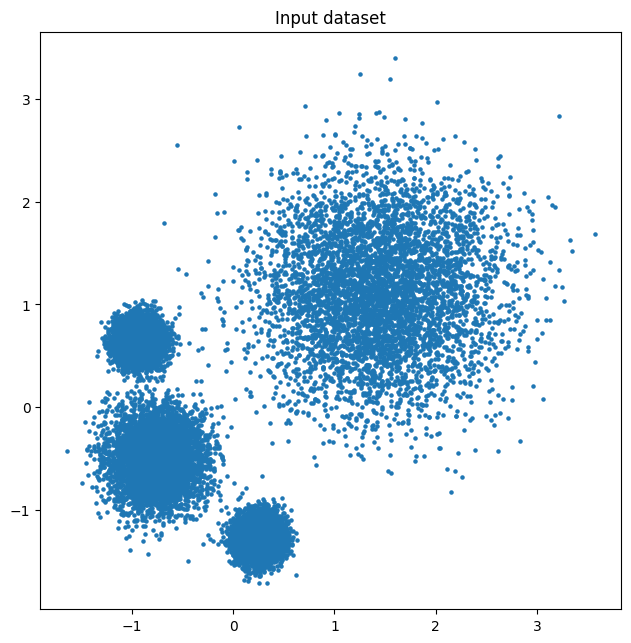

In [57]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "varied-variances.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

CA for each iteration: 	0.999	0.999	0.999	0.999	0.999	0.999	0.999	0.999	0.999	0.999	

Avg. CA:  0.999

Avg. RI:  0.999

Avg. running time (sec):  0.5587
Graph size: 81479


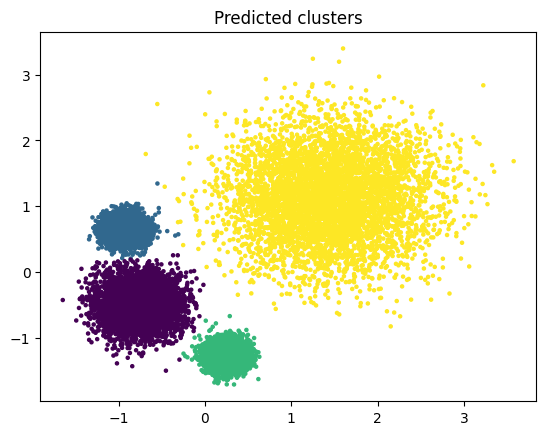

In [58]:
# set verbose=2 to save the results

nnz, RT, CAs, RIs, pred_labels = sbsc(X, K, num_iter=10, verbose=2, ds_name=filename, target_path=target_path)

print( "Graph size:", nnz )

# Visualizing results for 2-d datasets
if f == 2:
    max_ca_idx = np.argmax(CAs)
    # Plotting best results
    plt.scatter( X[:, 0], X[:, 1], c=pred_labels[:, max_ca_idx], s=5 )
    plt.title( 'Predicted clusters' )
    plt.show()

# Significance testing

In [59]:
from scipy.stats import ranksums

In [60]:
method_names = {'km': '$K$-means',
                'knnsc': '$k$NN-SC',
                'kasp': 'KASP',
                'dcdpasc': 'DCDP-ASC',
                'lsc-r': 'LSC-R',
                'lsc-k': 'LSC-K',
                'uspec': 'USPEC',
                'dnc': 'DnC'
}
method_names

{'km': '$K$-means',
 'knnsc': '$k$NN-SC',
 'kasp': 'KASP',
 'dcdpasc': 'DCDP-ASC',
 'lsc-r': 'LSC-R',
 'lsc-k': 'LSC-K',
 'uspec': 'USPEC',
 'dnc': 'DnC'}

(20000, 2) 4


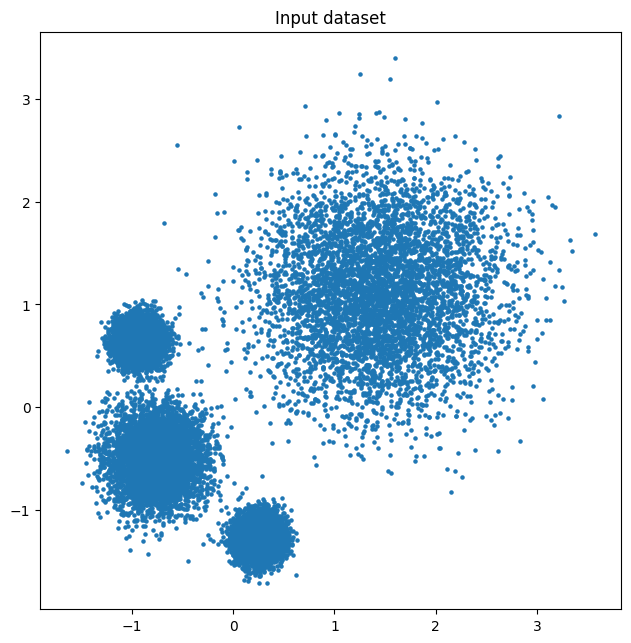

In [61]:
base_path = "/content/drive/MyDrive/sbsc/datasets/"
target_path = '' # path of the directory to save the results

filename, sep = "varied-variances.txt", "\t"

# loading the dataset
df = pd.read_csv(base_path + filename, sep=sep, header=None)
df, lab = df.iloc[:, :-1], df.iloc[:, -1].astype('int')

# K is the number of clusters, N is the number of data points, and f is the number of features
K = len(set(lab))
X = np.array(df, dtype='float32')
print(X.shape, K)

N, f = X.shape

if f == 2:
    plt.figure(plt.figure(figsize=(7.5, 7.5)))
    plt.scatter(X[:,0], X[:,1], color='C0', s=5)
    plt.title( 'Input dataset' )
    plt.show()

del df

In [75]:
# @title Select the method and run the cell
base_path = "" # @param
prop_method = 'sbsc'
method_2 = "uspec" # @param ["kasp", "lsc-r", "lsc-k", "uspec", "dnc", "knnsc", "dcdpasc", "km"]

# load the labels
prop_labels = pd.read_csv( base_path + '/sbsc-pred-labels-' + filename[:-4] + ".csv", header=None )
method_2_labels = pd.read_csv( base_path + '/' + method_2 + '-pred-labels-' + filename[:-4] + ".csv", header=None )

print(prop_labels.shape, method_2_labels.shape)

# Finding clustering accuracy

prop_cas = []
method_2_cas = []
N, num_labels = prop_labels.shape

for lab_no in range(num_labels):

    prop_cas.append( clustering_accuracy(lab, prop_labels.iloc[:, lab_no]) )
    method_2_cas.append( clustering_accuracy(lab, method_2_labels.iloc[:, lab_no]) )


print("CA of SBSC: ", prop_cas)
print("CA of", method_names[method_2], ": ", method_2_cas)

x, p = ranksums(prop_cas, method_2_cas)

print( "p value:", round(p, 5) )

(20000, 10) (20000, 10)
CA of SBSC:  [np.float64(0.999), np.float64(0.999), np.float64(0.999), np.float64(0.999), np.float64(0.999), np.float64(0.999), np.float64(0.999), np.float64(0.999), np.float64(0.999), np.float64(0.999)]
CA of USPEC :  [np.float64(0.9983), np.float64(0.9988), np.float64(0.74925), np.float64(0.7494), np.float64(0.9987), np.float64(0.9985), np.float64(0.9987), np.float64(0.99755), np.float64(0.9984), np.float64(0.99875)]
p value: 0.00016
